# MelodyMatch-V2 — Dataset Analysis

This notebook analyzes the frozen FMA Medium dataset used throughout the MelodyMatch-V2 experiments.

The analysis covers:

- Dataset size and split composition
- Genre distribution
- Train/validation/test class distributions
- Audio validation and cleaning
- Track duration statistics

The notebook is analysis-only. It does not modify the dataset, audio files, or experimental splits.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "clean_train.csv"
VAL_PATH = DATA_DIR / "clean_validation.csv"
TEST_PATH = DATA_DIR / "clean_test.csv"

VALIDATION_PATH = DATA_DIR / "audio_validation.csv"
REMOVED_PATH = DATA_DIR / "removed_tracks.csv"

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test:       {len(test_df):,}")
print(f"Total:      {len(train_df) + len(val_df) + len(test_df):,}")

Train:      19,904
Validation: 2,504
Test:       2,572
Total:      24,980


In [4]:
genre_counts = (
    pd.concat(
        [
            train_df.assign(split="Train"),
            val_df.assign(split="Validation"),
            test_df.assign(split="Test"),
        ]
    )
    .groupby("genre")
    .size()
    .sort_values(ascending=False)
)

genre_counts

genre
Rock                   7098
Electronic             6311
Experimental           2250
Hip-Hop                2192
Folk                   1518
Instrumental           1349
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
dtype: int64

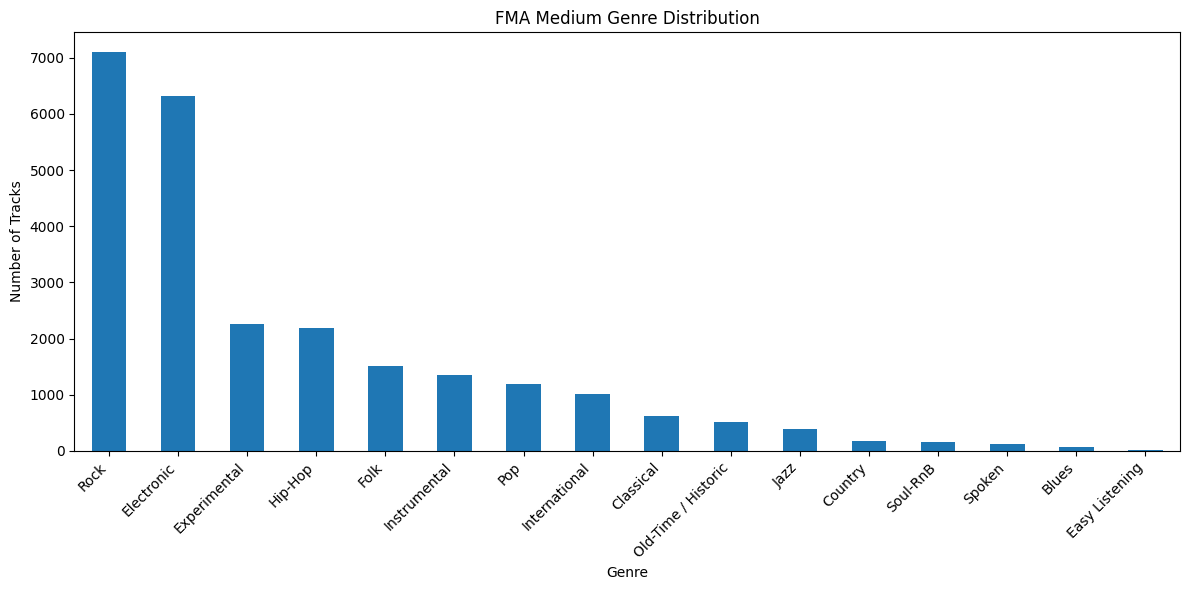

In [5]:
plt.figure(figsize=(12, 6))

genre_counts.plot(kind="bar")

plt.title("FMA Medium Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [6]:
split_counts = pd.Series(
    {
        "Train": len(train_df),
        "Validation": len(val_df),
        "Test": len(test_df),
    }
)

split_counts

Train         19904
Validation     2504
Test           2572
dtype: int64

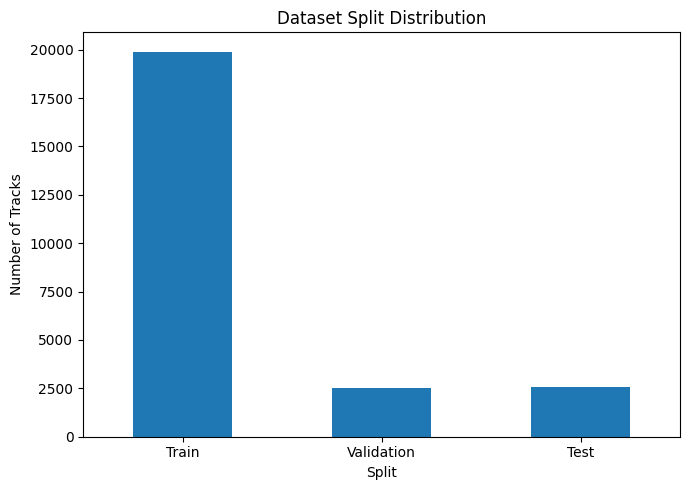

In [7]:
plt.figure(figsize=(7, 5))

split_counts.plot(kind="bar")

plt.title("Dataset Split Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [8]:
combined_df = pd.concat(
    [
        train_df.assign(split="Train"),
        val_df.assign(split="Validation"),
        test_df.assign(split="Test"),
    ],
    ignore_index=True,
)

split_genre = pd.crosstab(
    combined_df["genre"],
    combined_df["split"],
)

split_genre

split,Test,Train,Validation
genre,,,
Blues,8,58,8
Classical,62,495,62
Country,18,142,18
Easy Listening,6,13,2
Electronic,632,5048,631
Experimental,225,1800,225
Folk,152,1214,152
Hip-Hop,220,1752,220
Instrumental,174,1044,131


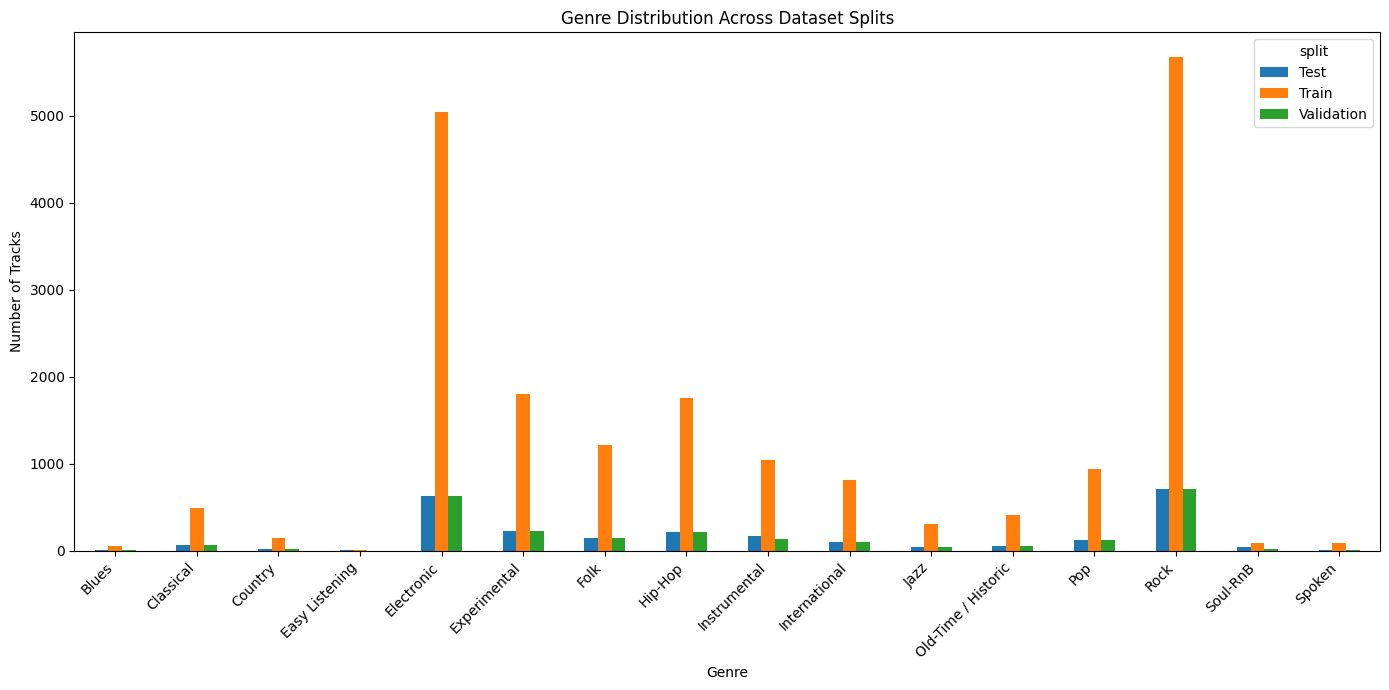

In [9]:
split_genre.plot(
    kind="bar",
    figsize=(14, 7),
)

plt.title("Genre Distribution Across Dataset Splits")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [12]:
removed_df = pd.read_csv(REMOVED_PATH)

removal_summary = (
    removed_df["removal_reason"]
    .value_counts()
    .rename_axis("Removal Reason")
    .reset_index(name="Count")
)

removal_summary

,Removal Reason,Count
0,invalid_audio,15
1,duration_under_10_seconds,5


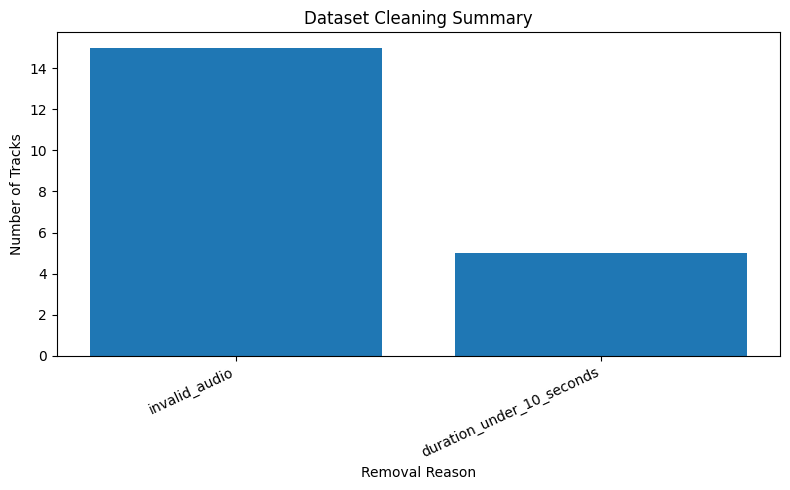

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    removal_summary["Removal Reason"],
    removal_summary["Count"],
)

plt.title("Dataset Cleaning Summary")
plt.xlabel("Removal Reason")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.show()

In [15]:
validation_df = pd.read_csv(VALIDATION_PATH)

valid_audio = validation_df[
    validation_df["valid"] == True
].copy()

print(f"Valid audio files: {len(valid_audio):,}")
print(f"Invalid audio files: {(validation_df['valid'] == False).sum():,}")

Valid audio files: 24,985
Invalid audio files: 15


In [16]:
valid_audio["duration"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    24985.000000
mean        29.982623
std          0.379476
min          0.536576
1%          29.976576
5%          29.976576
25%         29.976576
50%         29.976576
75%         30.002698
95%         30.002698
99%         30.002698
max         30.007469
Name: duration, dtype: float64

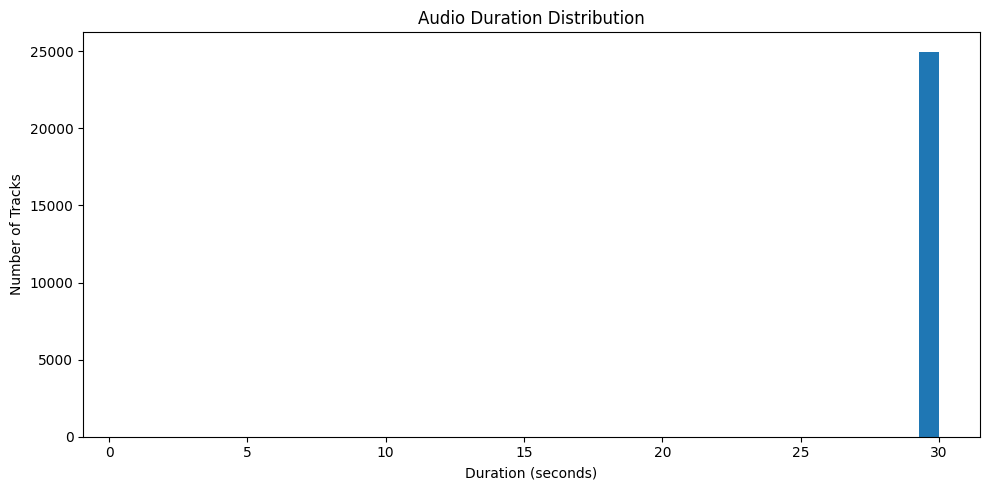

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_audio["duration"],
    bins=40,
)

plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Tracks")
plt.tight_layout()

plt.show()

In [18]:
largest_class = genre_counts.max()
smallest_class = genre_counts.min()

print("Largest class:", genre_counts.idxmax(), largest_class)
print("Smallest class:", genre_counts.idxmin(), smallest_class)
print(
    f"Imbalance ratio: {largest_class / smallest_class:.2f}:1"
)

Largest class: Rock 7098
Smallest class: Easy Listening 21
Imbalance ratio: 338.00:1
